In [51]:
import pandas as pd

In [52]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
FILEPATH = '/content/drive/MyDrive/bayyin_dataset.csv'

In [54]:
bayyin_dataset_df = pd.read_csv(FILEPATH)

In [55]:
bayyin_dataset_df.head()

,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Document,Source,Book,Author,Domain,Text_Class,Dataset_Source
0,10102480006,انظر يا فهمان..,5,انظر يا فهمان . .,نظر يا فهمان . .,انظر يا فهمان . .,نظر يا فهمان . .,2,BAREC_Majed_1686_2011_027.txt,Majed,Edition: 1686,#,Arts & Humanities,Foundational,BAREC
1,30400010076,تشجع الدولة الديمقراطية القائمة على المشاركة على مستوى السلطات المحلية.,11,تشجع الدولة الديمقراطية القائمة على المشاركة على مستوى السلطات المحلية .,شجع دولة ديمقراطي قائم على مشاركة على مستوى سلطة محلي .,تشجع ال+ دولة ال+ ديمقراطية ال+ قائمة على ال+ مشاركة على مستوى ال+ سلطات ال+ محلية .,شجع ال+ دولة ال+ ديمقراطي ال+ قائم على ال+ مشاركة على مستوى ال+ سلطة ال+ محلي .,5,BAREC_MCWC_Algeria_001.txt,Constitutions,Algeria's Constitution,#,Social Sciences,Specialized,BAREC
2,30500230021,رسولُ اللّهِ والحياةُ الاجتماعيّةُ,4,رسول الله والحياة الاجتماعية,رسول الله حياة ٱجتماعي,رسول الله و+ ال+ حياة ال+ اجتماعية,رسول الله و+ ال+ حياة ال+ ٱجتماعي,3,BAREC_Curriculum_12_slm_t1_u01_001.txt,Emarati Curriculum,Grade 12 Islamic Studies,#,Arts & Humanities,Specialized,BAREC
3,20200330009,س: ما هي عاصمة ألبانيا؟ (أ) تيرانا (ب) ساوتومي (ج) كتمندو,19,س : ما هي عاصمة ألبانيا ؟ ( أ ) تيرانا ( ب ) ساوتومي ( ج ) كتمندو,س : ما هي عاصمة ألبانيا ؟ ( أ ) تيرانا ( ب ) ساوتومي ( ج ) تمندو,س : ما هي عاصمة ألبانيا ؟ ( أ ) تيرانا ( ب ) ساوتومي ( ج ) ك+ تمندو,س : ما هي عاصمة ألبانيا ؟ ( أ ) تيرانا ( ب ) ساوتومي ( ج ) ك+ تمندو,4,BAREC_ArabicMMLU_Group_16_010.txt,ArabicMMLU,#,#,Arts & Humanities,Advanced,BAREC
4,20101750010,وظلت مأهولة لمدة 700 سنة أخرى على الأقل، كجماعة مسيحية لاتينية، ثم كمستوطنة إسلامية مبكرة.,18,"وظلت مأهولة لمدة 700 سنة أخرى على الأقل , كجماعة مسيحية لاتينية , ثم كمستوطنة إسلامية مبكرة .","ظل مأهول مدة 700 سنة أخرى على أقل , جماعة مسيحي لاتيني , ثم مستوطنة إسلامي مبكر .","و+ ظلت مأهولة ل+ مدة 700 سنة أخرى على ال+ أقل , ك+ جماعة مسيحية لاتينية , ثم ك+ مستوطنة إسلامية مبكرة .","و+ ظل مأهول ل+ مدة 700 سنة أخرى على ال+ أقل , ك+ جماعة مسيحي لاتيني , ثم ك+ مستوطنة إسلامي مبكر .",5,BAREC_Wikipedia_وليلي_001.txt,Wikipedia,Volubilis,#,Social Sciences,Advanced,BAREC


In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_intermediate_distribution(df):
    """
    Visualizes Domain and Text_Class distribution for Levels 3, 4, and 5
    to verify the structural and thematic separation.
    """
    # Filter for the three intermediate target levels [cite: 310, 680]
    target_levels = df[df['Readability_Level'].isin([3, 4, 5])].copy()

    # Set up the visualization with two side-by-side plots [cite: 43, 46]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Domain Distribution: Checking STEM vs Arts vs Social Sciences overlap [cite: 325, 353]
    sns.countplot(data=target_levels, x='Readability_Level', hue='Domain', ax=axes[0], palette='viridis')
    axes[0].set_title('Domain Distribution: Levels 3, 4, & 5')
    axes[0].set_ylabel('Count of Sentences')

    # 2. Text_Class Distribution: Verifying the 15/35/50 split and Specialized priority [cite: 388, 882]
    sns.countplot(data=target_levels, x='Readability_Level', hue='Text_Class', ax=axes[1], palette='magma')
    axes[1].set_title('Text_Class Distribution: Levels 3, 4, & 5')
    axes[1].set_ylabel('Count of Sentences')

    plt.tight_layout()
    plt.show()

    # Summary Statistics for numerical confirmation [cite: 42, 48]
    text_class_pivot = target_levels.groupby(['Readability_Level', 'Text_Class']).size().unstack(fill_value=0)
    print("--- Text Class Representation counts ---")
    print(text_class_pivot)

    return text_class_pivot

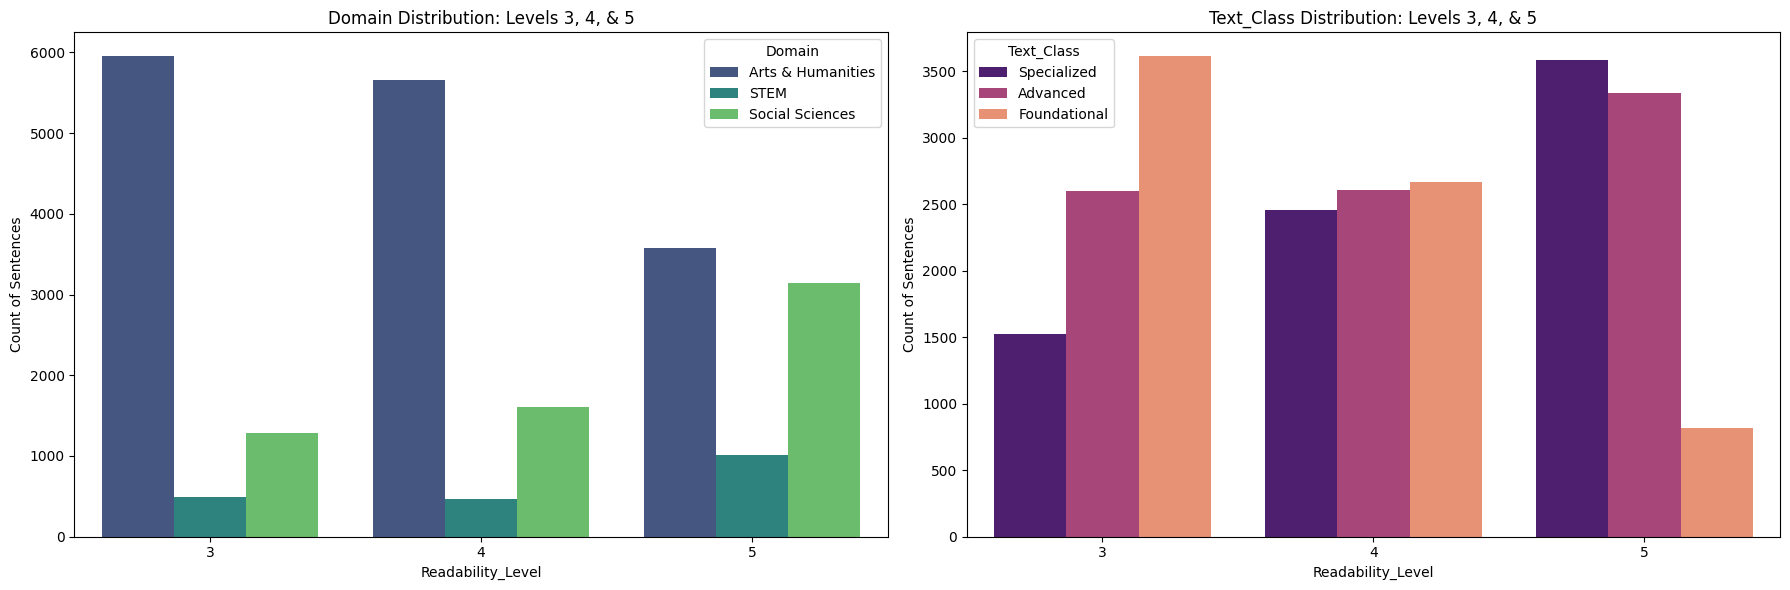

--- Text Class Representation counts ---
Text_Class         Advanced  Foundational  Specialized
Readability_Level                                     
3                      2598          3612         1525
4                      2609          2670         2456
5                      3333           819         3583


In [57]:
domain_stats = analyze_intermediate_distribution(bayyin_dataset_df)

In [58]:

from datasets import load_dataset
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("CAMeL-Lab/BAREC-Corpus-v1.0")

In [59]:

train_df = ds['train'].to_pandas()
dev_df = ds['dev'].to_pandas()
test_df = ds['test'].to_pandas()

BAREC_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)
pd.set_option('display.max_colwidth', None)
BAREC_df.head()

,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,مجلة كل الأولاد وكل البنات,مجلة كل ولد كل بنت,مجلة كل ال+ أولاد و+ كل ال+ بنات,مجلة كل ال+ ولد و+ كل ال+ بنت,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,ماجد,ماجد,ماجد,ماجد,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,الأربعاء 21 يناير 1987,أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,ال+ أربعاء 21 يناير 1987,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
3,10100290004,الموافق 21 جمادى الأول 1407هــ,6,الموافق 21 جمادى الأول 1407ه,موافق 21 جمادى أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,ال+ موافق 21 جمادى ال+ أول 1407 ه,7-zay,7,2,1,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
4,10100290005,السنة الثامنة,2,السنة الثامنة,سنة ثامن,ال+ سنة ال+ ثامنة,ال+ سنة ال+ ثامن,5-ha,5,2,1,1,A4,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_intermediate_distribution(df):
    """
    Visualizes Domain and Text_Class distribution for Levels 3, 4, and 5
    to verify the structural and thematic separation.
    """
    # Filter for the three intermediate target levels [cite: 310, 680]
    target_levels = df[df['Readability_Level_7'].isin([4, 5, 6])].copy()

    # Set up the visualization with two side-by-side plots [cite: 43, 46]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Domain Distribution: Checking STEM vs Arts vs Social Sciences overlap [cite: 325, 353]
    sns.countplot(data=target_levels, x='Readability_Level_7', hue='Domain', ax=axes[0], palette='viridis')
    axes[0].set_title('Domain Distribution: Levels 3, 4, & 5')
    axes[0].set_ylabel('Count of Sentences')

    # 2. Text_Class Distribution: Verifying the 15/35/50 split and Specialized priority [cite: 388, 882]
    sns.countplot(data=target_levels, x='Readability_Level_7', hue='Text_Class', ax=axes[1], palette='magma')
    axes[1].set_title('Text_Class Distribution: Levels 3, 4, & 5')
    axes[1].set_ylabel('Count of Sentences')

    plt.tight_layout()
    plt.show()

    # Summary Statistics for numerical confirmation [cite: 42, 48]
    text_class_pivot = target_levels.groupby(['Readability_Level', 'Text_Class']).size().unstack(fill_value=0)
    print("--- Text Class Representation counts ---")
    print(text_class_pivot)

    return text_class_pivot

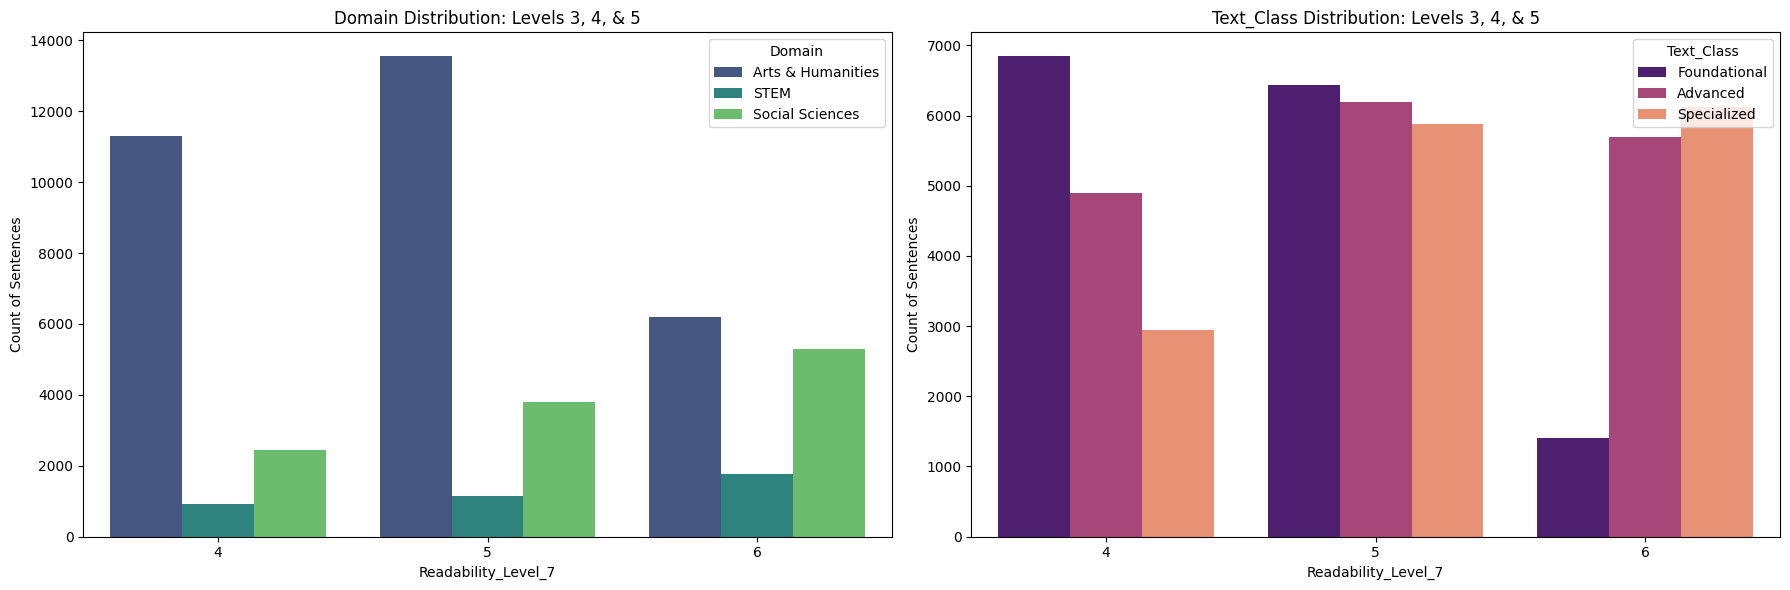

--- Text Class Representation counts ---
Text_Class         Advanced  Foundational  Specialized
Readability_Level                                     
10-ya                  3091          4828         1844
11-kaf                 1801          2016         1097
12-lam                 4978          5158         4335
13-mim                 1216          1275         1548
14-nun                 4724          1322         4641
15-sin                  974            88         1485


In [61]:
domain_stats = analyze_intermediate_distribution(BAREC_df)

In [62]:
import pandas as pd

def refine_intermediate_levels(df, barec_df, target_size=7735):
    """
    Solves Level 4/5 confusion by creating a 'Morphological Force Gap'.
    Fixed to handle cases where 'Foundational' counts are low.
    """
    # 1. Preserve stable levels (1, 2, 6)
    final_df = df[~df['Readability_Level'].isin([3, 4, 5])].copy()

    # 2. Add 'Morph_Complexity' feature (using raw string r'\+' to fix SyntaxWarning)
    barec_df = barec_df.copy()
    barec_df['Morph_Complexity'] = barec_df['D3Tok'].str.count(r'\+') # [cite: 326, 438]

    # 3. New Level 3: BAREC-7 '4' (100% Foundational)
    l3_pool = barec_df[(barec_df['Readability_Level_7'] == 4) &
                       (barec_df['Text_Class'] == 'Foundational')]
    actual_l3_size = min(target_size, len(l3_pool))
    new_l3 = l3_pool.sample(n=actual_l3_size, random_state=42)
    new_l3['Readability_Level'] = 3

    # 4. New Level 4: Hybrid Distribution with Safety Checks
    l5_pool = barec_df[barec_df['Readability_Level_7'] == 5].copy()

    def safe_n_select(pool, size, sort_by_col, largest=False):
        # Prevent 'sample larger than population' error for nlargest/nsmallest
        actual_size = min(size, len(pool))
        if largest:
            return pool.nlargest(actual_size, sort_by_col, keep='first')
        else:
            return pool.nsmallest(actual_size, sort_by_col, keep='first')

    # Target specific distribution [cite: 881, 882]
    count_found = int(target_size * 0.15)
    count_adv = int(target_size * 0.35)

    l4_found = safe_n_select(l5_pool[l5_pool['Text_Class'] == 'Foundational'], count_found, 'Morph_Complexity', largest=False)
    l4_adv = safe_n_select(l5_pool[l5_pool['Text_Class'] == 'Advanced'], count_adv, 'Morph_Complexity', largest=False)

    # Calculate remainder to reach exactly target_size, taking into account what was actually sampled
    current_count_l4 = len(l4_found) + len(l4_adv)
    l4_spec = safe_n_select(l5_pool[l5_pool['Text_Class'] == 'Specialized'], target_size - current_count_l4, 'Morph_Complexity', largest=False)

    new_l4 = pd.concat([l4_found, l4_adv, l4_spec])
    new_l4['Readability_Level'] = 4

    # 5. New Level 5: BAREC-7 '6' (Top complexity Specialized/Advanced)
    l6_pool = barec_df[(barec_df['Readability_Level_7'] == 6) &
                       (barec_df['Text_Class'].isin(['Specialized', 'Advanced']))]
    actual_l5_size = min(target_size, len(l6_pool))
    new_l5 = l6_pool.nlargest(actual_l5_size, 'Morph_Complexity') # [cite: 438, 878]
    new_l5['Readability_Level'] = 5

    # 6. Assemble and Shuffle
    assembled_df = pd.concat([final_df, new_l3, new_l4, new_l5]).reset_index(drop=True)
    return assembled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Run the fixed replacement
df_bayyin_forced = refine_intermediate_levels(bayyin_dataset_df, BAREC_df)

Number of samples in each level:
Readability_Level
1    7735
2    7735
3    6844
4    7735
5    7735
6    7735
Name: count, dtype: int64


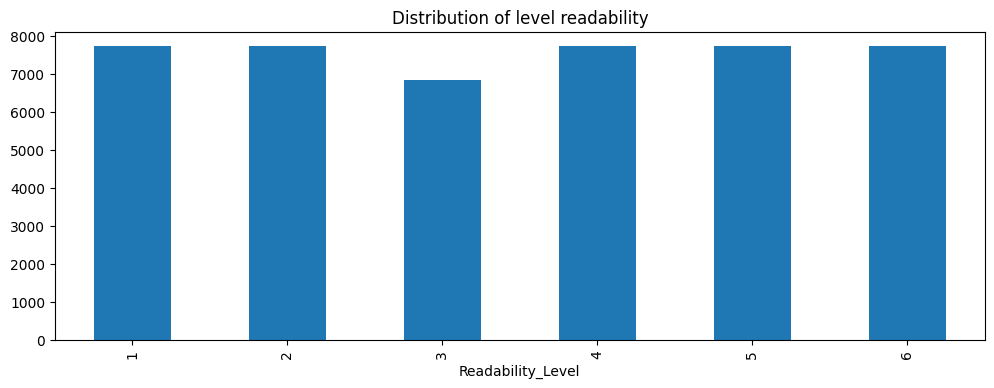

In [63]:
samples_per_level = df_bayyin_forced["Readability_Level"].value_counts().sort_index()
print("Number of samples in each level:")
print(samples_per_level)

df_bayyin_forced["Readability_Level"].value_counts().sort_index().plot(kind="bar", figsize=(12,4))
plt.title("Distribution of level readability")
plt.show()

In [64]:
total_samples = df_bayyin_forced.shape[0]

print(f"Total number of samples in the combined dataset: {total_samples}")

Total number of samples in the combined dataset: 45519


In [65]:
print(df_bayyin_forced.columns.tolist())

['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class', 'Dataset_Source', 'Readability_Level_19', 'Readability_Level_7', 'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Morph_Complexity']


In [66]:
columns_to_drop = ['Readability_Level_7','Readability_Level_19', 'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Morph_Complexity']
df = df_bayyin_forced.drop(columns=columns_to_drop)

In [67]:
# Use .loc to target specific rows (Readability_Level 3, 4, 5)
# and the specific column (Dataset_Source)
df.loc[df['Readability_Level'].isin([3, 4, 5]), 'Dataset_Source'] = 'BAREC'

# Verify the update
print(df[df['Readability_Level'].isin([3, 4, 5])]['Dataset_Source'].value_counts())

Dataset_Source
BAREC    22314
Name: count, dtype: int64


Number of samples in each readability level:
Readability_Level
1    7735
2    7735
3    6844
4    7735
5    7735
6    7735
Name: count, dtype: int64


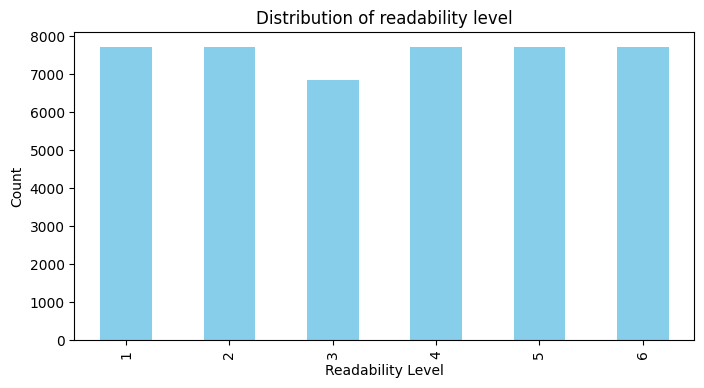

In [68]:
samples_per_level = df["Readability_Level"].value_counts().sort_index()
print("Number of samples in each readability level:")
print(samples_per_level)

samples_per_level.plot(
    kind="bar", figsize=(8,4), color="skyblue"
)
plt.title("Distribution of readability level")
plt.xlabel("Readability Level")
plt.ylabel("Count")
plt.show()

In [69]:
df = df.drop_duplicates(subset=["Sentence"])

print("Shape of the DataFrame after removing duplicate sentences:")
print(df.shape)

print("\nNumber of samples in each readability level after removing duplicate sentences:")
print(df["Readability_Level"].value_counts().sort_index())

Shape of the DataFrame after removing duplicate sentences:
(44917, 15)

Number of samples in each readability level after removing duplicate sentences:
Readability_Level
1    7735
2    7735
3    6689
4    7316
5    7707
6    7735
Name: count, dtype: int64


In [70]:
import re

arabic_chars = re.compile(r'[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDCF\uFDF0-\uFDFF\uFE70-\uFEFF\u0020-\u002F\u0030-\u0039\u003A-\u0040\u005B-\u0060\u007B-\u007E\u00A0-\u00BF\u2000-\u206F\u2E00-\u2E7F\u3000-\u303F\uFE30-\uFE4F]+')

def find_non_arabic_chars(text):
    non_arabic = []
    for char in text:
        if not arabic_chars.fullmatch(char):
             non_arabic.append(char)
    return non_arabic

non_arabic_characters_found = set()

for sentence in df["Sentence"]:
    for word in str(sentence).split():
        non_arabic_chars_in_word = find_non_arabic_chars(word)
        if non_arabic_chars_in_word:
            non_arabic_characters_found.update(non_arabic_chars_in_word)

if non_arabic_characters_found:
    print("Non-Arabic characters found:")
    print(non_arabic_characters_found)
else:
    print("No non-standard Arabic or common punctuation characters found.")

count_sentences_with_non_arabic = 0

for sentence in df["Sentence"]:
    has_non_arabic = False
    for char in str(sentence):
        if char in non_arabic_characters_found:
            has_non_arabic = True
            break
    if has_non_arabic:
        count_sentences_with_non_arabic += 1

print(f"Number of sentences containing non-Arabic characters: {count_sentences_with_non_arabic}")

Non-Arabic characters found:
{'з', 'ç', 'í', '�', 'Y', '华', '⁸', 'ː', 'յ', 'B', 'k', 'е', 'М', '綢', 'κ', 'Հ', 'Β', 'σ', 'й', 'ϱ', 'ה', 'ⴱ', '÷', 'д', 'έ', '✓', 'ó', 'ɵ', 'ⲥ', '́', 'Г', 'ß', 'π', '✘', 'ओ', 'Р', 'L', 'п', 'ї', 'V', 'ⴷ', 'អ', 'ə', 'г', 'O', 'វ', 'A', 'л', 'ɑ', 'R', 'e', 'ό', 'r', 'D', 'W', 'P', 'ν', '\uf0fc', 'S', 'α', 'Э', 'ⵔ', 'р', 'ˈ', 'ῆ', 'j', 'Γ', '丸', 'ל', 'о', '丝', 'ⵎ', 'ί', 'क', 'н', 'э', '×', 'F', 'G', '\uf06d', '✔', 'é', '國', 'l', '華', 'а', '台', 'ऀ', 'w', '\uf0fb', 'ħ', 'à', 'U', 'ς', 'v', 'מ', 'x', 'τ', 'ᵻ', '−', '国', 'H', '之', 'כ', 'В', '旗', 'X', '្', 'ⵉ', 'י', 'ü', 'я', 'I', 'χ', 'ή', 'ⲗ', 'ь', 'の', 'E', 'Б', 'с', 'ж', 'ρ', 'ϰ', 'ⲡ', 'ⲕ', 'a', 'פ', 'ύ', 'q', 'f', 'ы', '\uf0a7', 'ⵏ', 'រ', 'ш', '绸', '臺', 'λ', 'կ', '\uf076', 'ר', 'K', 'p', 'м', 'd', 'y', 'ά', 'g', 'M', 'ἀ', 'Φ', 'ע', 'к', 'ⵍ', '日', 'и', 't', '▫', '絲', 'ⲟ', '灣', 'ⵖ', 'ת', 'Z', 'ο', '✗', 'т', 'T', 'γ', 'h', 'è', 'b', 'ı', 'μ', 'i', '湾', 'ε', 'Q', 's', 'æ', 'C', 'm', 'ḗ', 'ⴰ', 'J', 'ⴳ', 'o', 'ա', 

In [71]:

# Remove non arabic chars
arabic_chars_only = re.compile(r'[^[\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDCF\uFDF0-\uFDFF\uFE70-\uFEFF]]+')

def remove_non_arabic(text):
    if isinstance(text, str):
        return arabic_chars_only.sub('', text)
    return text

df.loc[:, "Sentence"] = df["Sentence"].apply(remove_non_arabic)

In [72]:

# Remove Tashkeel
tashkeel_chars = re.compile(r'[\u064B-\u0652\u06D6-\u06DC\u06DF-\u06E4\u06E7-\u06E8\u06EA-\u06ED]')

def remove_tashkeel(text):
    if isinstance(text, str):
        return tashkeel_chars.sub('', text)
    return text

df.loc[:, "Sentence"] = df["Sentence"].apply(remove_tashkeel)

In [73]:
df.head()

,ID,Sentence,Word_Count,Word,Lex,D3Tok,D3Lex,Readability_Level,Document,Source,Book,Author,Domain,Text_Class,Dataset_Source
0,20100850006,تتضمن آلات قياس الوقت القديمة أيضا، الساعة الشمعية التي استخدمت في الصين واليابان وإنجلترا والعراق، والمزولة التي انتشرت على نطاق واسع في الهند والتبت وأجزاء من أوروبا، والساعة الرملية وفكرتها مشابهة لفكرة الساعة المائية.,38,"تتضمن آلات قياس الوقت القديمة أيضا , الساعة الشمعية التي استخدمت في الصين واليابان وإنجلترا والعراق , والمزولة التي انتشرت على نطاق واسع في الهند والتبت وأجزاء من أوروبا , والساعة الرملية وفكرتها مشابهة لفكرة الساعة المائية .","تضمن آلة قياس وقت قديم أيضا , ساعة شمعي الذي ٱستخدم في صين يابان إنجلترا عراق , مزولة الذي ٱنتشر على نطاق واسع في هند تبت جزء من أوربا , ساعة رملي فكرة مشابه فكرة ساعة مائي .","تتضمن آلات قياس ال+ وقت ال+ قديمة أيضا , ال+ ساعة ال+ شمعية التي استخدمت في ال+ صين و+ ال+ يابان و+ أنجلترا و+ ال+ عراق , و+ ال+ مزولة التي انتشرت على نطاق واسع في ال+ هند و+ ال+ تبت و+ أجزاء من أوروبا , و+ ال+ ساعة ال+ رملية و+ فكرة +ها مشابهة ل+ فكرة ال+ ساعة ال+ مائية .","تضمن آلة قياس ال+ وقت ال+ قديم أيضا , ال+ ساعة ال+ شمعي الذي ٱستخدم في ال+ صين و+ ال+ يابان و+ إنجلترا و+ ال+ عراق , و+ ال+ مزولة الذي ٱنتشر على نطاق واسع في ال+ هند و+ ال+ تبت و+ جزء من أوربا , و+ ال+ ساعة ال+ رملي و+ فكرة +ها مشابه ل+ فكرة ال+ ساعة ال+ مائي .",5,BAREC_Wikipedia_تاريخ_آلات_قياس_الوقت_001.txt,Wikipedia,History of Algeria,#,Social Sciences,Advanced,BAREC
1,10400440098,الآباء المؤسسون,2,الآباء المؤسسون,أب مؤسس,ال+ آباء ال+ مؤسسون,ال+ أب ال+ مؤسس,2,BAREC_Curriculum_04_soc_t1_u01_001.txt,Emarati Curriculum,Grade 4 Social Sciences,#,Social Sciences,Foundational,BAREC
2,59130386_707,^(٤ )إن القليل من النقوش التي بقيت من الأسطر ٥–٧ ليس له مقابل في اللوحات الجنازية رقم ١٩٢-١٩٣ ٢٤٠ من لوحات السربيوم الموجودة في متحف «اللوفر»، والظاهر أن الموضوع ينحصر في أمر صادر من الملك وتنفيذه.,36,"^ ( ٤ ) إن القليل من النقوش التي بقيت من الأسطر ٥ - ٧ ليس له مقابل في اللوحات الجنازية رقم ١٩٢ - ١٩٣ ٢٤٠ من لوحات السربيوم الموجودة في متحف "" اللوفر "" , والظاهر أن الموضوع ينحصر في أمر صادر من الملك وتنفيذه .","^ ( ٤ ) أن قليل من نقش الذي بقي من سطر ٥ - ٧ ليس ل مقابل في لوحة جنازي رقم ١٩٢ - ١٩٣ ٢٤٠ من لوحة سربيوم موجود في متحف "" لوفر "" , ظاهر أن موضوع ٱنحصر في أمر صادر من ملك تنفيذ .","^ ( ٤ ) أن ال+ قليل من ال+ نقش الذي بقي من ال+ سطر ٥ - ٧ ليس ل +ه مقابل في ال+ لوحة ال+ جنازي رقم ١٩٢ - ١٩٣ ٢٤٠ من لوحة ال+ سربيوم ال+ موجود في متحف "" ال+ لوفر "" , و+ ال+ ظاهر أن ال+ موضوع ٱنحصر في أمر صادر من ال+ ملك و+ تنفيذ +ه .","^ ( ٤ ) أن ال+ قليل من ال+ نقش الذي بقي من ال+ سطر ٥ - ٧ ليس ل +ه مقابل في ال+ لوحة ال+ جنازي رقم ١٩٢ - ١٩٣ ٢٤٠ من لوحة ال+ سربيوم ال+ موجود في متحف "" ال+ لوفر "" , و+ ال+ ظاهر أن ال+ موضوع ٱنحصر في أمر صادر من ال+ ملك و+ تنفيذ +ه .",6,NaN,Arabic E-Books,موسوعة مصر القديمة (الجزء الثالث عشر): من العهد الفارسي إلى دخول الإسكندر الأكبر وبه لمحات في تاريخ السودان وفارس وقصة قناة السويس قديمًا,سليم حسن,Arts & Humanities,NaN,Arabic E-Book Corpus
3,20400050070,اذكر وظيفة الملائكة الواردة في السورة، مبينا الحكمة من ذلك.,12,"اذكر وظيفة الملائكة الواردة في السورة , مبينا الحكمة من ذلك .","ذكر وظيفة ملأك وارد في سورة , مبين حكمة من ذلك .","أذكر وظيفة ال+ ملائكة ال+ واردة في ال+ سورة , مبينا ال+ حكمة من ذلك .","ذكر وظيفة ال+ ملأك ال+ وارد في ال+ سورة , مبين ال+ حكمة من ذلك .",4,BAREC_Curriculum_05_slm_t1_u01_001.txt,Emarati Curriculum,Grade 5 Islamic Studies,#,Arts & Humanities,Advanced,BAREC
4,10200050018,معنى كلمة المارة في الجملة التالية:الطريق للمارة تعني (أ) الإشارة (ب) المرأة (ج) الساعون (د) المشاة,26,معنى كلمة المارة في الجملة التالية : الطريق للمارة تعني ( أ ) الإشارة ( ب ) المرأة ( ج ) الساعون ( د ) المشاة,معنى كلمة مار في جملة تالي : طريق مار عنى ( أ ) إشارة ( ب ) مرأة ( ج ) ساعي ( د ) ماشي,معنى كلمة ال+ مارة في ال+ جملة ال+ تالية : ال+ طريق ل+ ال+ مارة تعني ( أ ) ال+ إشارة ( ب ) ال+ مرأة ( ج ) ال+ ساعون ( د ) ال+ مشاة,معنى كلمة ال+ مار في ال+ جملة ال+ تالي : ال+ طريق ل+ ال+ مار عنى ( أ ) ال+ إشارة ( ب ) ال+ مرأة ( ج ) ال+ ساعي ( د ) ال+ ماشي,3,BAREC_ArabicMMLU_Group_1_005.txt,ArabicMMLU,#,#,Arts 

In [74]:
print("Number of null/missing values in each column:")
print(df.isnull().sum())

Number of null/missing values in each column:
ID                      0
Sentence                0
Word_Count              0
Word                    0
Lex                     0
D3Tok                   0
D3Lex                   0
Readability_Level       0
Document             6103
Source                  0
Book                    0
Author                  0
Domain                  0
Text_Class           6440
Dataset_Source          0
dtype: int64


In [75]:
# Normalization
def normalize_arabic(text):
    if isinstance(text, str):
        text = re.sub(r'[إأآا]', 'ا', text)
        text = re.sub(r'ى', 'ي', text)
        text = re.sub(r'ؤ', 'و', text)
        text = re.sub(r'ئ', 'ي', text)
        text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
        return text
    return text

df["Sentence"] = df["Sentence"].apply(normalize_arabic)

print("DataFrame with Normalized Sentences:")
display(df["Sentence"].head())

DataFrame with Normalized Sentences:


,Sentence
0,تتضمن الات قياس الوقت القديمة ايضا الساعة الشمعية التي استخدمت في الصين واليابان وانجلترا والعراق والمزولة التي انتشرت علي نطاق واسع في الهند والتبت واجزاء من اوروبا والساعة الرملية وفكرتها مشابهة لفكرة الساعة المايية
1,الاباء الموسسون
2,٤ ان القليل من النقوش التي بقيت من الاسطر ٥٧ ليس له مقابل في اللوحات الجنازية رقم ١٩٢١٩٣ ٢٤٠ من لوحات السربيوم الموجودة في متحف اللوفر والظاهر ان الموضوع ينحصر في امر صادر من الملك وتنفيذه
3,اذكر وظيفة الملايكة الواردة في السورة مبينا الحكمة من ذلك
4,معني كلمة المارة في الجملة التاليةالطريق للمارة تعني ا الاشارة ب المراة ج الساعون د المشاة


In [76]:
# Remove stop words
import nltk
from nltk.corpus import stopwords

try:
    stopwords.words('arabic')
except LookupError:
    nltk.download('stopwords')

arabic_stop_words = set(stopwords.words('arabic'))

def remove_stop_words(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in arabic_stop_words]
    return tokens

df["Sentence"] = df["Sentence"].apply(remove_stop_words)

print("DataFrame with Tokens after Stop Word Removal:")
display(df["Sentence"].head())

DataFrame with Tokens after Stop Word Removal:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Sentence
0,تتضمن الات قياس الوقت القديمة ايضا الساعة الشمعية التي استخدمت في الصين واليابان وانجلترا والعراق والمزولة التي انتشرت علي نطاق واسع في الهند والتبت واجزاء من اوروبا والساعة الرملية وفكرتها مشابهة لفكرة الساعة المايية
1,الاباء الموسسون
2,٤ ان القليل من النقوش التي بقيت من الاسطر ٥٧ ليس له مقابل في اللوحات الجنازية رقم ١٩٢١٩٣ ٢٤٠ من لوحات السربيوم الموجودة في متحف اللوفر والظاهر ان الموضوع ينحصر في امر صادر من الملك وتنفيذه
3,اذكر وظيفة الملايكة الواردة في السورة مبينا الحكمة من ذلك
4,معني كلمة المارة في الجملة التاليةالطريق للمارة تعني ا الاشارة ب المراة ج الساعون د المشاة


In [77]:
# Stemming
from nltk.stem.isri import ISRIStemmer

try:
    ISRIStemmer()
except LookupError:
    nltk.download('isri')

st = ISRIStemmer()

def stem_tokens(tokens):
    if isinstance(tokens, list):
        return [st.stem(word) for word in tokens]
    return tokens

df["Sentence"] = df["Sentence"].apply(stem_tokens)

print("DataFrame with Stemmed Tokens:")
display(df["Sentence"].head())

DataFrame with Stemmed Tokens:


,Sentence
0,تتضمن الات قياس الوقت القديمة ايضا الساعة الشمعية التي استخدمت في الصين واليابان وانجلترا والعراق والمزولة التي انتشرت علي نطاق واسع في الهند والتبت واجزاء من اوروبا والساعة الرملية وفكرتها مشابهة لفكرة الساعة المايية
1,الاباء الموسسون
2,٤ ان القليل من النقوش التي بقيت من الاسطر ٥٧ ليس له مقابل في اللوحات الجنازية رقم ١٩٢١٩٣ ٢٤٠ من لوحات السربيوم الموجودة في متحف اللوفر والظاهر ان الموضوع ينحصر في امر صادر من الملك وتنفيذه
3,اذكر وظيفة الملايكة الواردة في السورة مبينا الحكمة من ذلك
4,معني كلمة المارة في الجملة التاليةالطريق للمارة تعني ا الاشارة ب المراة ج الساعون د المشاة


In [78]:
# 1. Shuffle the entire dataframe
# frac=1 means take 100% of the rows, random_state ensures reproducibility
df_shuffled= df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Save the shuffled, balanced dataset to Google Drive
# Make sure you have already run: from google.colab import drive; drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Refined_Bayyin_Dataset.csv'
df_shuffled.to_csv(save_path, index=False)

print(f"Dataset shuffled and saved to: {save_path}")

Dataset shuffled and saved to: /content/drive/MyDrive/Refined_Bayyin_Dataset.csv
